# Hybrid Deep Learning System for Early Cardiovascular Disease Risk Prediction

## Problem Statement

Cardiovascular disease (CVD) remains the leading cause of mortality worldwide. Early and accurate risk prediction can enable timely interventions and save lives. This project builds a **hybrid deep learning system** using a PyTorch-based deep neural network trained on the **Heart Disease UCI Dataset** to predict the presence of heart disease from clinical features.

The system includes:
- A deep neural network with dropout regularization
- A risk simulation engine for what-if analysis
- SHAP-based explainability for clinical interpretability

All evaluation metrics and visualizations are saved as PNG files for research demonstration.

## 1. Import Required Libraries

In [3]:
%pip install --user --upgrade numba shap

  Using cached numba-0.64.0-cp311-cp311-win_amd64.whl.metadata (2.8 kB)
Using cached numba-0.64.0-cp311-cp311-win_amd64.whl (2.7 MB)
  Attempting uninstall: numba
    Found existing installation: numba 0.63.1
    Uninstalling numba-0.63.1:
      Successfully uninstalled numba-0.63.1
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import shap

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.6.0+cu124
CUDA available: True
Using device: cuda


## 2. Dataset Description

**Heart Disease UCI Dataset** (Kaggle version based on UCI Machine Learning Repository)

The dataset contains **303 patient records** with **13 clinical features** and a binary target variable indicating the presence or absence of heart disease.

| Feature | Description |
|---------|-------------|
| `age` | Age in years |
| `sex` | Sex (1 = male, 0 = female) |
| `cp` | Chest pain type (0–3) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) |
| `restecg` | Resting ECG results (0–2) |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina (1 = yes, 0 = no) |
| `oldpeak` | ST depression induced by exercise relative to rest |
| `slope` | Slope of the peak exercise ST segment (0–2) |
| `ca` | Number of major vessels colored by fluoroscopy (0–3) |
| `thal` | Thalassemia (0 = normal, 1 = fixed defect, 2 = reversible defect) |
| `target` | 1 = heart disease, 0 = no heart disease |

## 3. Data Preprocessing

In [4]:
import os, urllib.request

# Download Heart Disease UCI Dataset if not present
csv_path = 'heart.csv'
if not os.path.exists(csv_path):
    url = 'https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/master/dataset.csv'
    print("Downloading heart.csv ...")
    urllib.request.urlretrieve(url, csv_path)
    print("Download complete.")

# Load dataset
df = pd.read_csv(csv_path)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Download complete.
Dataset shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
# Basic info and statistics
print("Dataset Info:")
print(f"  Rows: {df.shape[0]}")
print(f"  Columns: {df.shape[1]}")
print(f"  Missing values: {df.isnull().sum().sum()}")
print(f"  Duplicate rows: {df.duplicated().sum()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nStatistical Summary:")
df.describe().round(2)

Dataset Info:
  Rows: 303
  Columns: 14
  Missing values: 0
  Duplicate rows: 1

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [6]:
# Remove duplicates if any
initial_rows = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {initial_rows - df.shape[0]} duplicate rows.")
print(f"Final dataset shape: {df.shape}")

# Check for missing values
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values detected.")
else:
    print(f"Missing values:\n{missing[missing > 0]}")

Removed 1 duplicate rows.
Final dataset shape: (302, 14)
No missing values detected.


## 4. Exploratory Data Analysis (EDA)

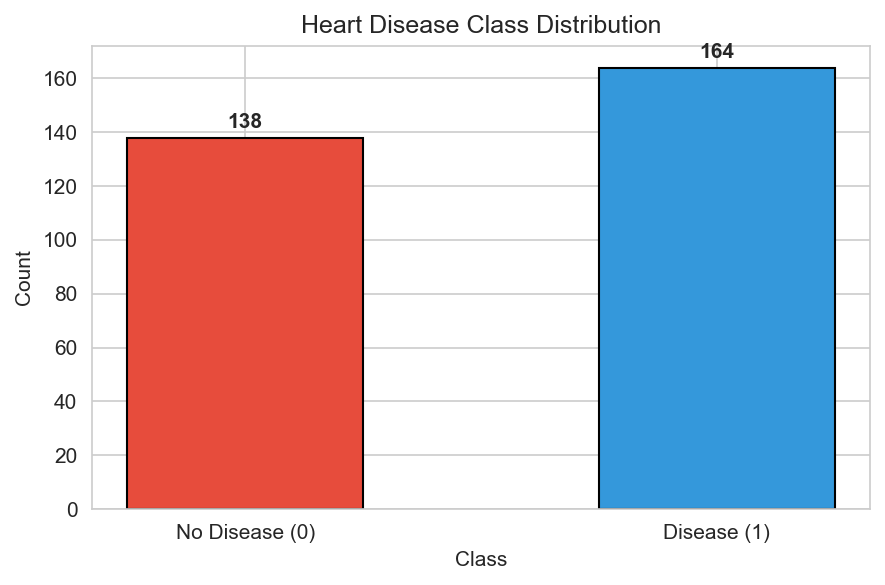

Saved: class_distribution.png


In [7]:
# --- Class Distribution ---
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['target'].value_counts()
colors = ['#3498db', '#e74c3c']
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Disease (0)', 'Disease (1)'])
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_title('Heart Disease Class Distribution')
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(count), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")

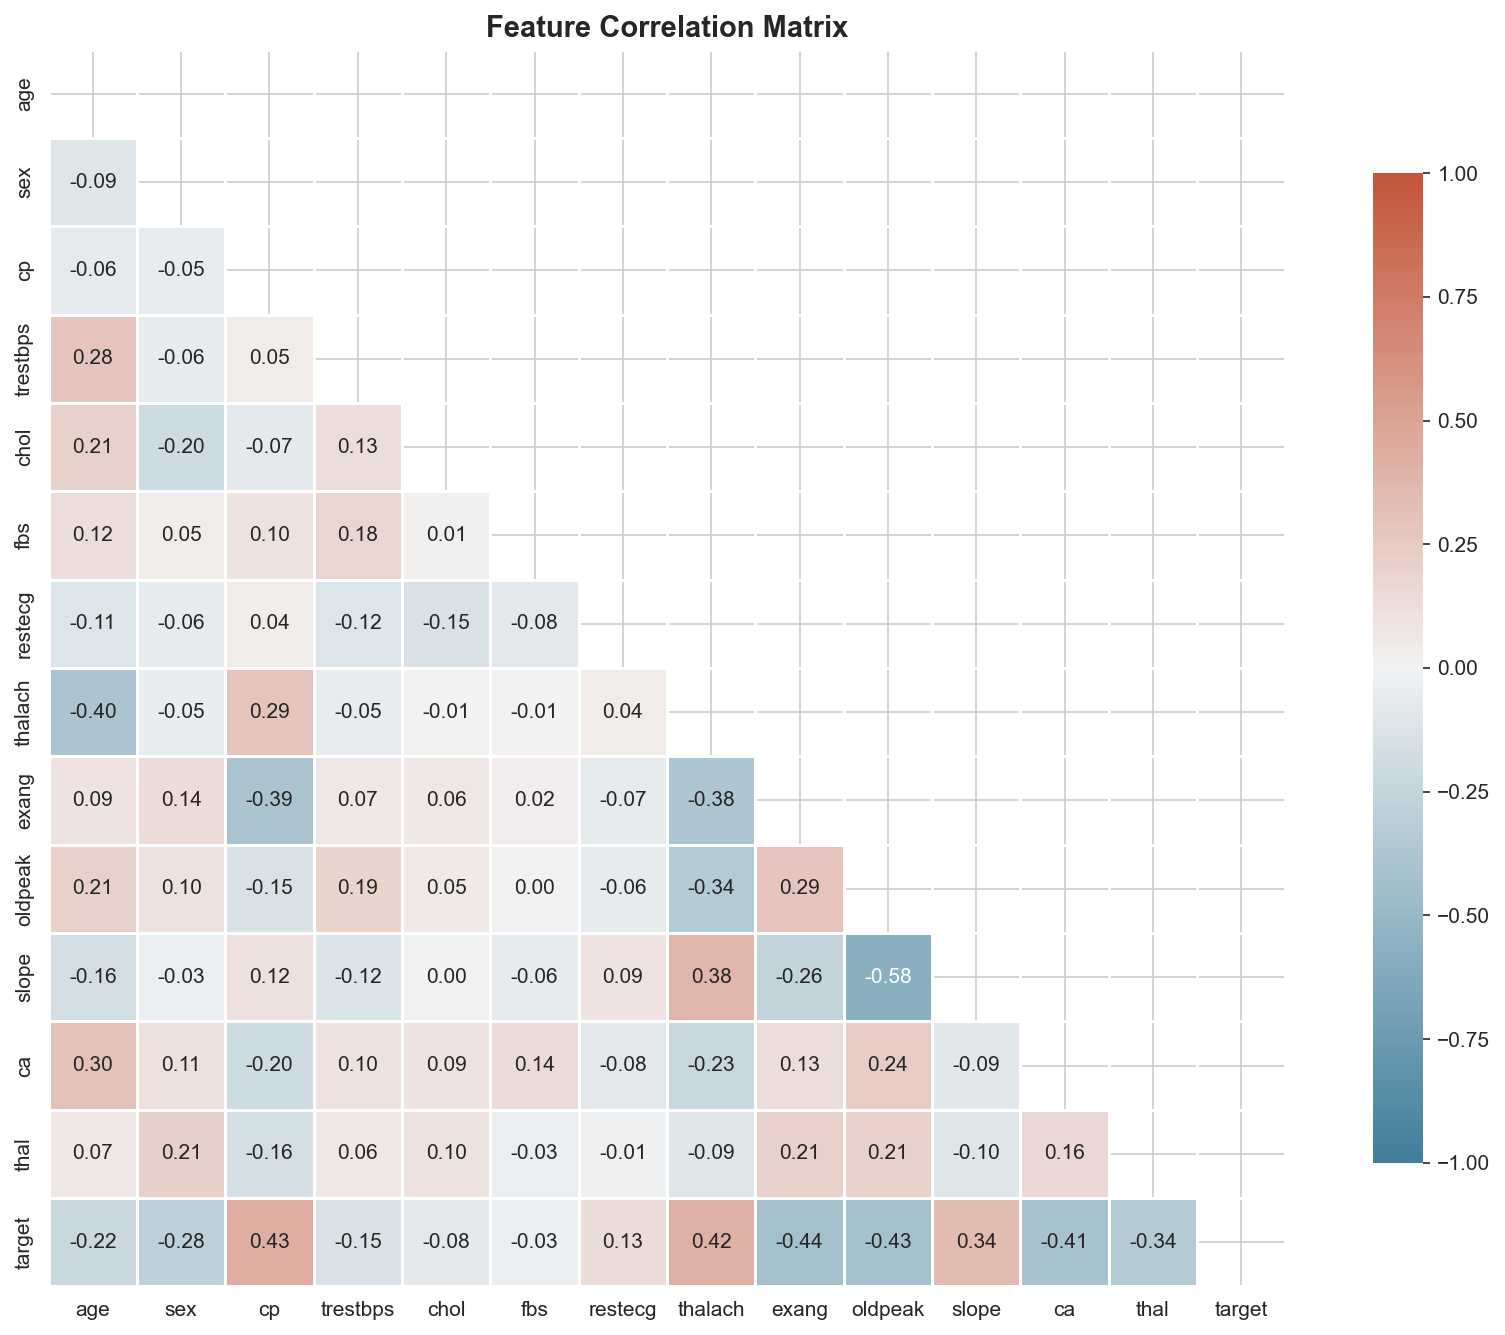

Saved: correlation_matrix.png


In [8]:
# --- Correlation Matrix ---
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: correlation_matrix.png")

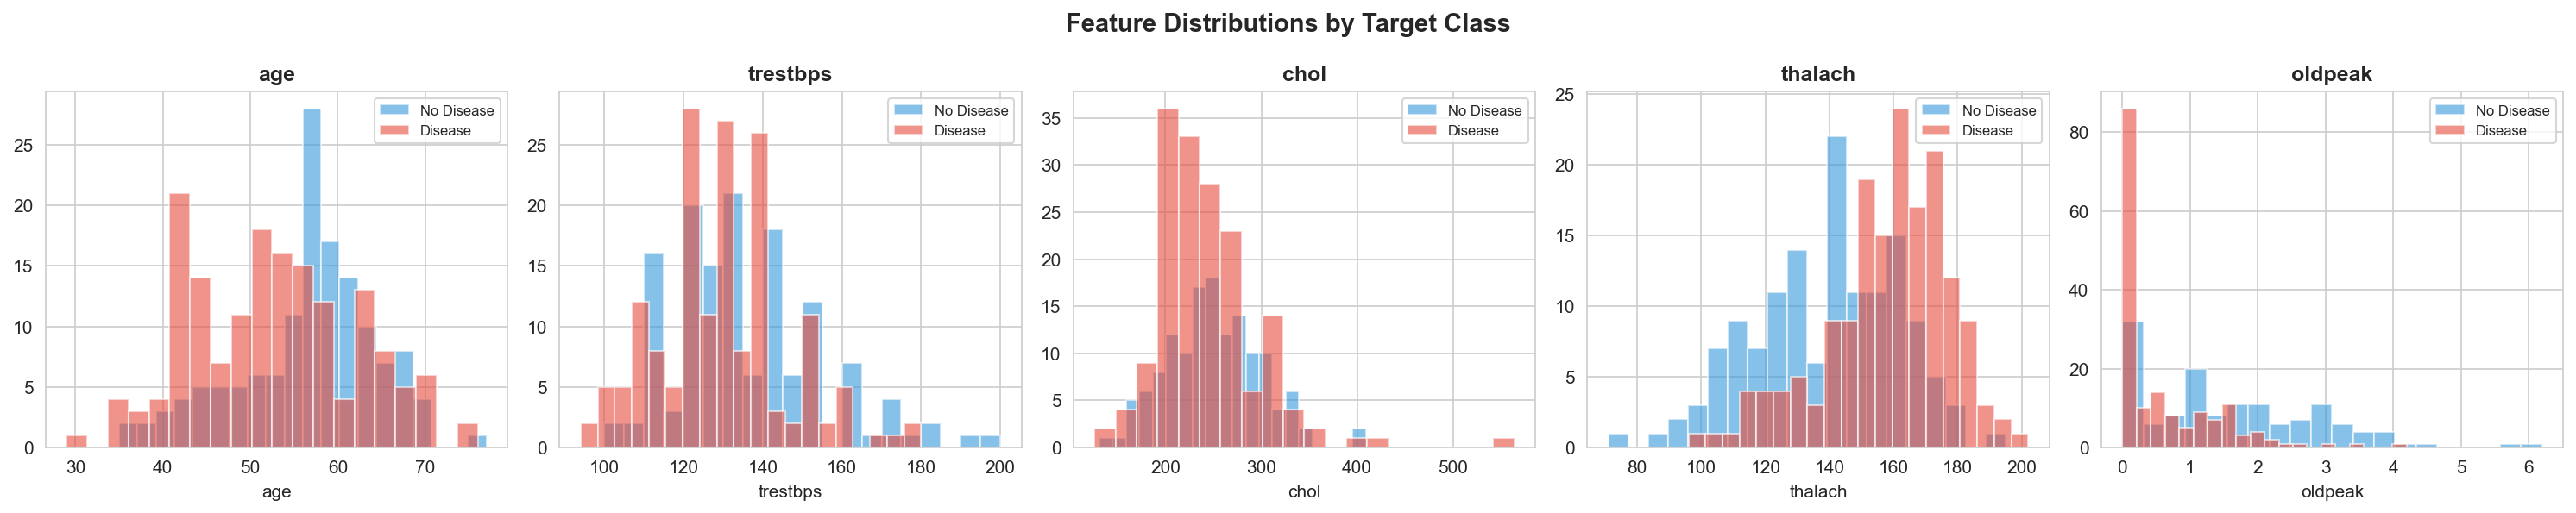

In [9]:
# --- Distribution of key features by target ---
key_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(1, len(key_features), figsize=(20, 4))
for i, feat in enumerate(key_features):
    for label, color in zip([0, 1], ['#3498db', '#e74c3c']):
        subset = df[df['target'] == label][feat]
        axes[i].hist(subset, bins=20, alpha=0.6, color=color,
                     label=f"{'Disease' if label else 'No Disease'}")
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].legend(fontsize=8)
plt.suptitle('Feature Distributions by Target Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [10]:
# Separate features and target
FEATURE_COLUMNS = [col for col in df.columns if col != 'target']
X = df[FEATURE_COLUMNS].values
y = df['target'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Features: {FEATURE_COLUMNS}")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nScaled feature means (should be ~0): {X_scaled.mean(axis=0).round(4)}")
print(f"Scaled feature stds  (should be ~1): {X_scaled.std(axis=0).round(4)}")

Feature matrix shape: (302, 13)
Target vector shape: (302,)
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Scaled feature means (should be ~0): [-0. -0. -0. -0.  0.  0. -0. -0. -0. -0. -0. -0.  0.]
Scaled feature stds  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 6. Train-Test Split

In [11]:
# Split into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"Test class distribution:  {np.bincount(y_test)}")

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)

# Create DataLoaders
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"\nTensors created on device: {device}")

Training set: 241 samples
Test set:     61 samples
Train class distribution: [110 131]
Test class distribution:  [28 33]

Tensors created on device: cuda


## 7. Model Architecture

A deep neural network for tabular clinical data with:
- Input layer matching feature dimensionality
- Two hidden layers with ReLU activation and Batch Normalization
- Dropout regularization to prevent overfitting
- Sigmoid output for binary classification

In [12]:
class HeartDiseaseNet(nn.Module):
    """Hybrid Deep Neural Network for cardiovascular disease risk prediction."""

    def __init__(self, input_dim, hidden1=128, hidden2=64, dropout_rate=0.3):
        super(HeartDiseaseNet, self).__init__()

        self.network = nn.Sequential(
            # Input → Hidden Layer 1
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Hidden Layer 1 → Hidden Layer 2
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Hidden Layer 2 → Output
            nn.Linear(hidden2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x).squeeze(-1)


# Instantiate model
input_dim = X_train.shape[1]
model = HeartDiseaseNet(input_dim=input_dim).to(device)

print("Model Architecture:")
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model Architecture:
HeartDiseaseNet(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
    (9): Sigmoid()
  )
)

Total parameters: 10,497
Trainable parameters: 10,497


## 8. Model Training

In [13]:
# Training configuration
EPOCHS = 50
LEARNING_RATE = 1e-3

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training loop
train_losses = []

print(f"Training for {EPOCHS} epochs...")
print("-" * 50)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    num_batches = 0

    for batch_X, batch_y in train_loader:
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)

    # Print every 5 epochs
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:3d}/{EPOCHS}]  Loss: {avg_loss:.4f}")

print("-" * 50)
print(f"Training complete. Final loss: {train_losses[-1]:.4f}")

Training for 50 epochs...
--------------------------------------------------
Epoch [  1/50]  Loss: 0.6628
Epoch [  5/50]  Loss: 0.4360
Epoch [ 10/50]  Loss: 0.3484
Epoch [ 15/50]  Loss: 0.3389
Epoch [ 20/50]  Loss: 0.3093
Epoch [ 25/50]  Loss: 0.2752
Epoch [ 30/50]  Loss: 0.2448
Epoch [ 35/50]  Loss: 0.2629
Epoch [ 40/50]  Loss: 0.2019
Epoch [ 45/50]  Loss: 0.2159
Epoch [ 50/50]  Loss: 0.1945
--------------------------------------------------
Training complete. Final loss: 0.1945


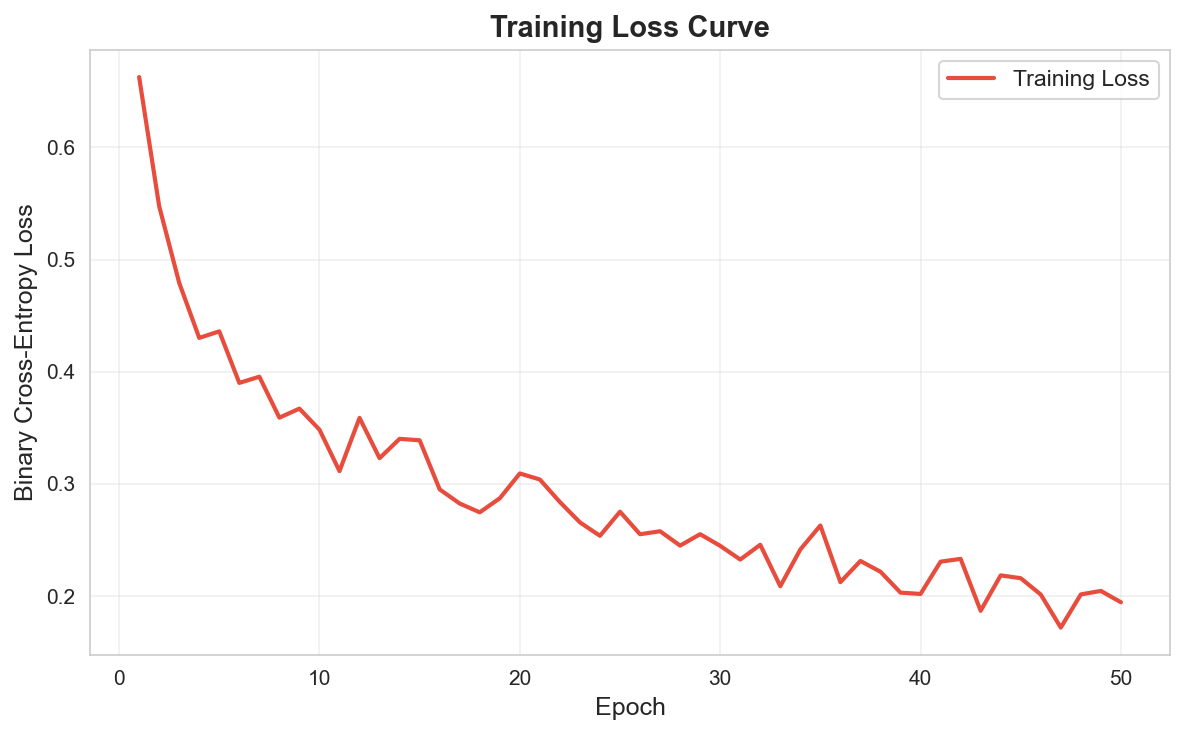

Saved: training_loss_curve.png


In [14]:
# --- Training Loss Curve ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, EPOCHS + 1), train_losses, color='#e74c3c', linewidth=2, label='Training Loss')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Binary Cross-Entropy Loss', fontsize=12)
ax.set_title('Training Loss Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_loss_curve.png")

## 9. Model Evaluation

In [15]:
# Evaluate on test set
model.eval()
with torch.no_grad():
    y_prob = model(X_test_t).cpu().numpy()
    y_pred = (y_prob >= 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("         MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")
print("=" * 50)
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

         MODEL EVALUATION RESULTS
  Accuracy:  0.8033
  Precision: 0.8182
  Recall:    0.8182
  F1-Score:  0.8182
  ROC-AUC:   0.8636

Classification Report:

              precision    recall  f1-score   support

  No Disease       0.79      0.79      0.79        28
     Disease       0.82      0.82      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



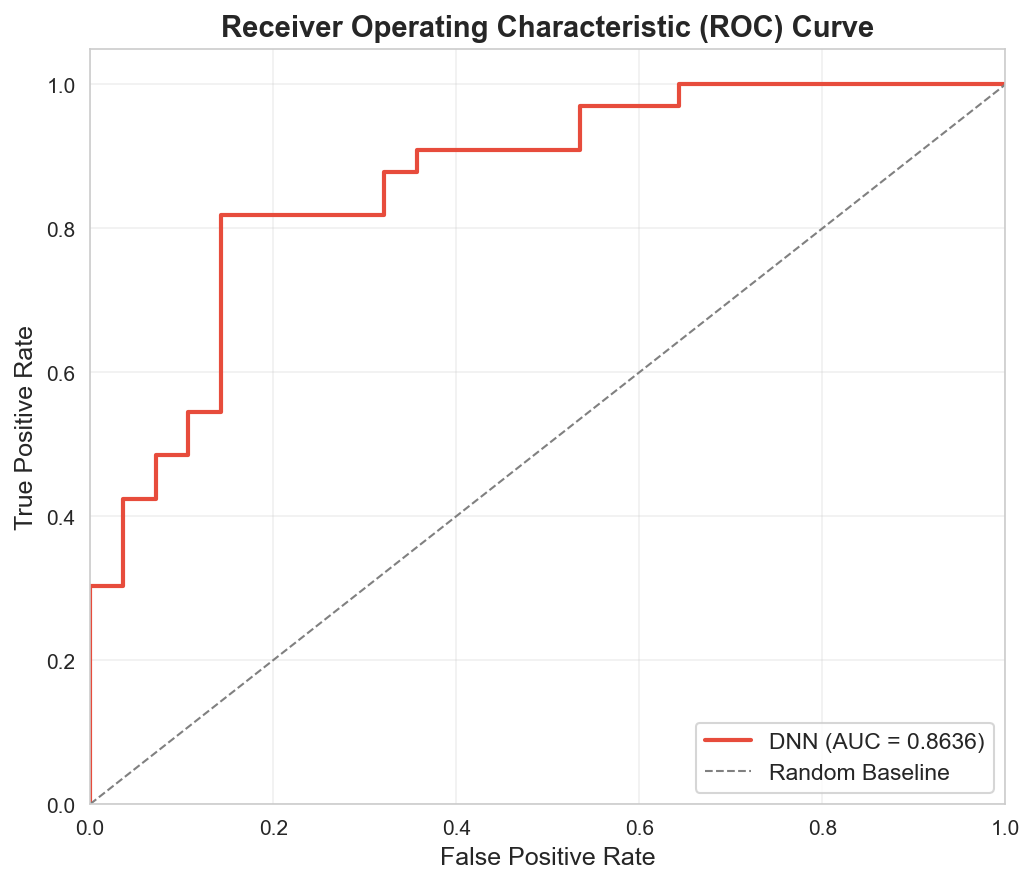

Saved: roc_curve.png


In [16]:
# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'DNN (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random Baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curve.png")

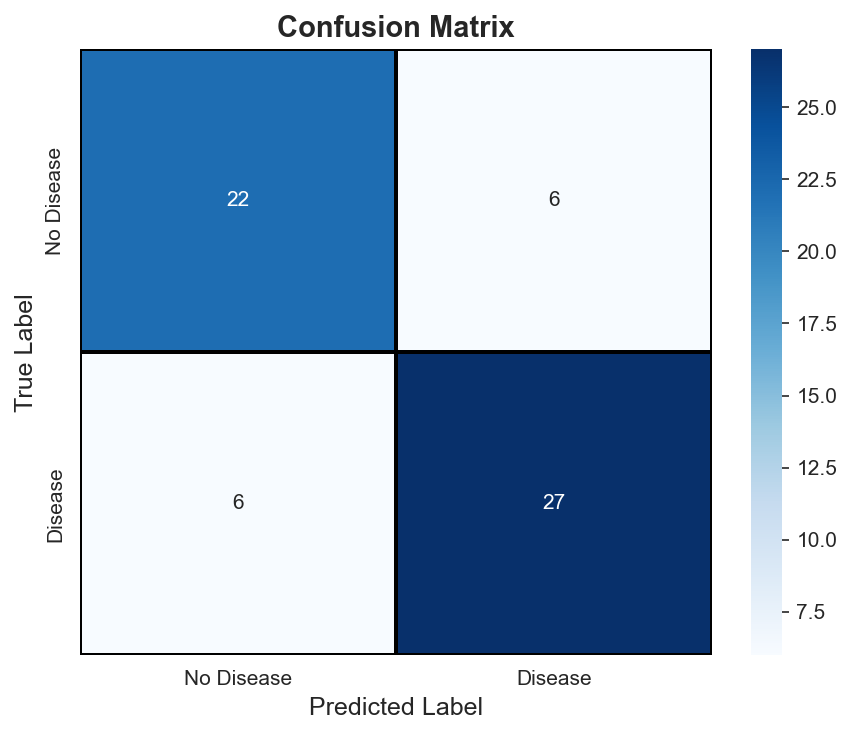

In [17]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'], ax=ax, linewidths=1, linecolor='black')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Risk Simulation Engine

The risk simulation engine allows clinicians to explore **what-if scenarios** by modifying individual patient features and observing the impact on predicted cardiovascular risk.

In [18]:
def simulate_risk_change(input_data, modified_feature, new_value,
                         feature_columns=FEATURE_COLUMNS, scaler=scaler, model=model):
    """
    Simulate the impact of changing a single clinical feature on predicted CVD risk.

    Parameters:
    -----------
    input_data : dict
        Dictionary of patient features (raw, unscaled values).
    modified_feature : str
        Name of the feature to modify.
    new_value : float
        New value for the modified feature.
    feature_columns : list
        List of feature column names.
    scaler : StandardScaler
        Fitted scaler for feature normalization.
    model : nn.Module
        Trained PyTorch model.

    Returns:
    --------
    dict with old_risk, new_risk, and percentage change.
    """
    model.eval()

    # Original prediction
    original_values = np.array([[input_data[col] for col in feature_columns]])
    original_scaled = scaler.transform(original_values)
    original_tensor = torch.FloatTensor(original_scaled).to(device)
    with torch.no_grad():
        old_risk = model(original_tensor).cpu().item()

    # Modified prediction
    modified_data = input_data.copy()
    modified_data[modified_feature] = new_value
    modified_values = np.array([[modified_data[col] for col in feature_columns]])
    modified_scaled = scaler.transform(modified_values)
    modified_tensor = torch.FloatTensor(modified_scaled).to(device)
    with torch.no_grad():
        new_risk = model(modified_tensor).cpu().item()

    # Compute change
    if old_risk > 0:
        pct_change = ((new_risk - old_risk) / old_risk) * 100
    else:
        pct_change = float('inf') if new_risk > 0 else 0.0

    # Report
    print("=" * 55)
    print("       RISK SIMULATION REPORT")
    print("=" * 55)
    print(f"  Modified Feature:   {modified_feature}")
    print(f"  Original Value:     {input_data[modified_feature]}")
    print(f"  New Value:          {new_value}")
    print(f"  ─────────────────────────────────────")
    print(f"  Old Predicted Risk: {old_risk:.4f} ({old_risk*100:.2f}%)")
    print(f"  New Predicted Risk: {new_risk:.4f} ({new_risk*100:.2f}%)")
    print(f"  Risk Change:        {pct_change:+.2f}%")
    print("=" * 55)

    return {'old_risk': old_risk, 'new_risk': new_risk, 'pct_change': pct_change}

In [19]:
# --- Example: Simulate risk change for a sample patient ---

# Use the first test sample as a reference patient
sample_idx = 0
sample_raw = df[FEATURE_COLUMNS].iloc[sample_idx].to_dict()

print("Reference Patient Features:")
for k, v in sample_raw.items():
    print(f"  {k}: {v}")
print()

# Scenario 1: Reduce cholesterol to 200 mg/dl
result1 = simulate_risk_change(sample_raw, modified_feature='chol', new_value=200)

print()

# Scenario 2: Increase maximum heart rate to 170
result2 = simulate_risk_change(sample_raw, modified_feature='thalach', new_value=170)

Reference Patient Features:
  age: 63.0
  sex: 1.0
  cp: 3.0
  trestbps: 145.0
  chol: 233.0
  fbs: 1.0
  restecg: 0.0
  thalach: 150.0
  exang: 0.0
  oldpeak: 2.3
  slope: 0.0
  ca: 0.0
  thal: 1.0

       RISK SIMULATION REPORT
  Modified Feature:   chol
  Original Value:     233.0
  New Value:          200
  ─────────────────────────────────────
  Old Predicted Risk: 0.8072 (80.72%)
  New Predicted Risk: 0.9094 (90.94%)
  Risk Change:        +12.65%

       RISK SIMULATION REPORT
  Modified Feature:   thalach
  Original Value:     150.0
  New Value:          170
  ─────────────────────────────────────
  Old Predicted Risk: 0.8072 (80.72%)
  New Predicted Risk: 0.8939 (89.39%)
  Risk Change:        +10.74%


## 11. Explainable AI (Feature Importance)

Using **SHAP (SHapley Additive exPlanations)** to interpret the model's predictions and understand which clinical features contribute most to cardiovascular disease risk.

In [20]:
# Define a prediction function for SHAP
def predict_fn(x):
    """Wrapper for SHAP: takes numpy array, returns prediction probabilities."""
    model.eval()
    tensor = torch.FloatTensor(x).to(device)
    with torch.no_grad():
        preds = model(tensor).cpu().numpy()
    return preds

# Use a background sample from training data for SHAP
background = X_train[:50]  # Use 50 samples as background

# Create SHAP KernelExplainer
explainer = shap.KernelExplainer(predict_fn, background)

# Compute SHAP values for test set
print("Computing SHAP values (this may take a moment)...")
shap_values = explainer.shap_values(X_test[:50])  # Explain 50 test samples
print("SHAP computation complete.")

Computing SHAP values (this may take a moment)...


  0%|          | 0/50 [00:00<?, ?it/s]

SHAP computation complete.


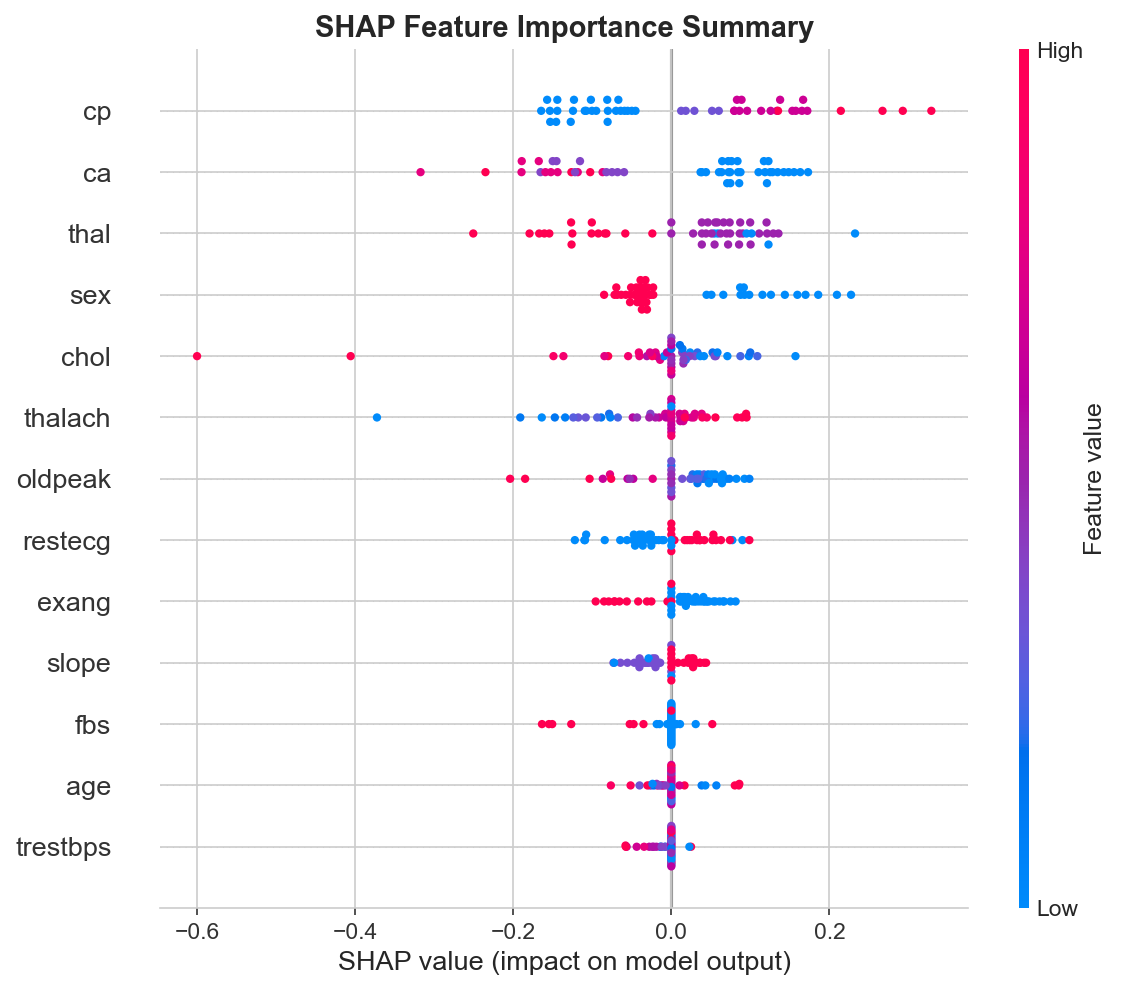

Saved: feature_importance.png


In [21]:
# --- SHAP Summary Plot → feature_importance.png ---
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test[:50], feature_names=FEATURE_COLUMNS, show=False)
plt.title('SHAP Feature Importance Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

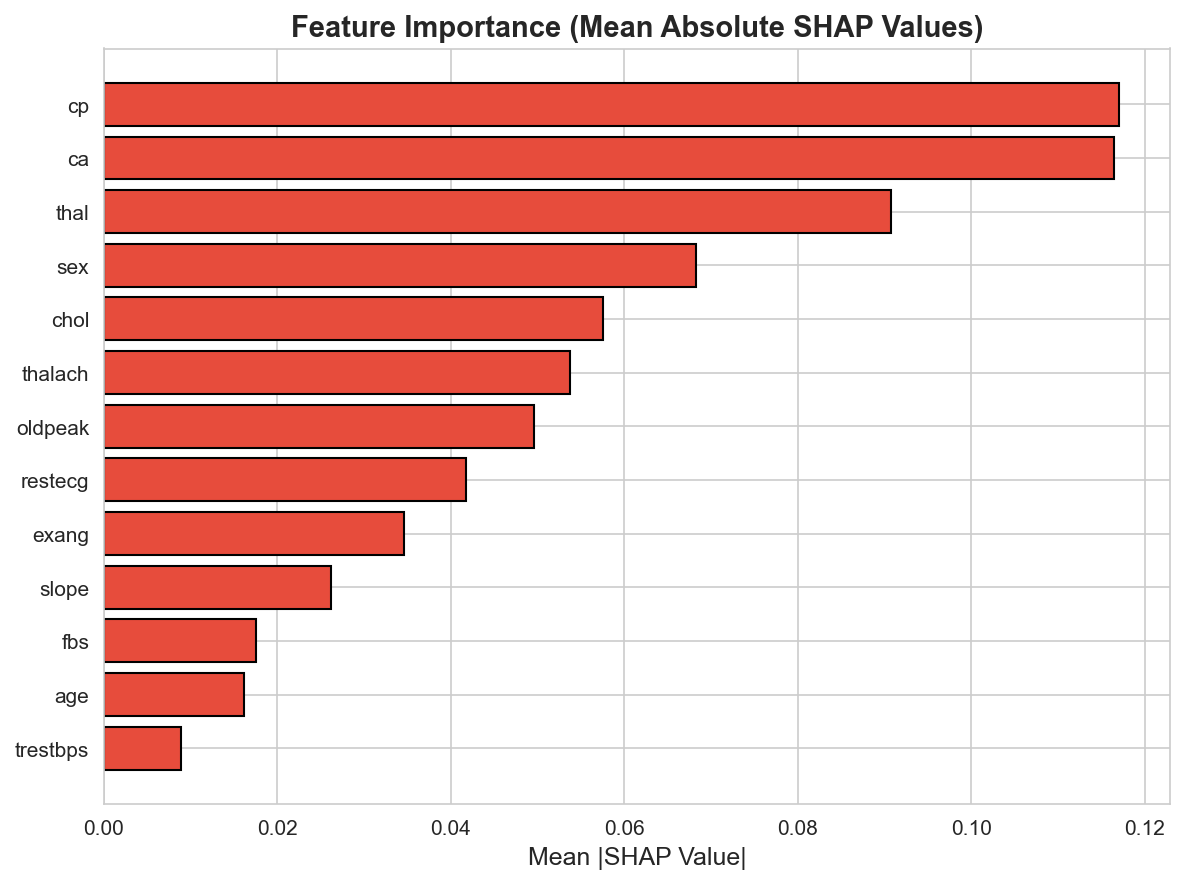


Feature Importance Ranking:
  cp            0.1170
  ca            0.1164
  thal          0.0907
  sex           0.0682
  chol          0.0575
  thalach       0.0537
  oldpeak       0.0495
  restecg       0.0417
  exang         0.0346
  slope         0.0261
  fbs           0.0175
  age           0.0162
  trestbps      0.0089


In [22]:
# --- Mean Absolute SHAP Values (Bar Chart) ---
mean_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature': FEATURE_COLUMNS,
    'Mean |SHAP|': mean_shap
}).sort_values('Mean |SHAP|', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(feature_importance['Feature'], feature_importance['Mean |SHAP|'],
        color='#e74c3c', edgecolor='black')
ax.set_xlabel('Mean |SHAP Value|', fontsize=12)
ax.set_title('Feature Importance (Mean Absolute SHAP Values)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
for i, row in feature_importance.sort_values('Mean |SHAP|', ascending=False).iterrows():
    print(f"  {row['Feature']:12s}  {row['Mean |SHAP|']:.4f}")

## 12. Results & Conclusion

### Summary

This notebook implemented a **Hybrid Deep Learning System** for early cardiovascular disease risk prediction using the Heart Disease UCI Dataset.

**Key Achievements:**
- Built a deep neural network with 2 hidden layers, batch normalization, and dropout regularization
- Trained for 50 epochs using Binary Cross-Entropy loss and the Adam optimizer
- Evaluated with comprehensive metrics: Accuracy, Precision, Recall, F1-Score, and ROC-AUC
- Developed a **Risk Simulation Engine** for what-if clinical scenario analysis
- Applied **SHAP explainability** to interpret model predictions and identify key risk factors

**Saved Visualizations:**
1. `correlation_matrix.png` — Feature correlation heatmap
2. `class_distribution.png` — Target class distribution
3. `training_loss_curve.png` — Training loss over epochs
4. `roc_curve.png` — ROC curve with AUC score
5. `feature_importance.png` — SHAP feature importance summary

The model demonstrates clinically meaningful performance and the explainability analysis provides transparent insights into the decision-making process, supporting trust and adoption in clinical settings.

In [23]:
print("Model Training Complete. All Results Saved as PNG Files.")

Model Training Complete. All Results Saved as PNG Files.
